In [10]:
#Libraries

import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns



In [2]:
data = 'https://raw.githubusercontent.com/Javier-Gutierrez/machine-learning-zoomcamp/refs/heads/main/cohorts/2026/data/car_fuel_efficiency_2026.csv'

In [3]:
#reading the csv

df = pd.read_csv(data)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 11 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   model_year           10000 non-null  int64  
 1   origin               10000 non-null  object 
 2   fuel_type            10000 non-null  object 
 3   drivetrain           10000 non-null  object 
 4   num_doors            10000 non-null  int64  
 5   engine_displacement  10000 non-null  int64  
 6   num_cylinders        10000 non-null  int64  
 7   horsepower           9123 non-null   float64
 8   vehicle_weight       10000 non-null  int64  
 9   acceleration         9736 non-null   float64
 10  fuel_efficiency_mpg  10000 non-null  float64
dtypes: float64(3), int64(5), object(3)
memory usage: 859.5+ KB


In [ ]:
#Looking for columns with null values
print(df.isnull().sum())

model_year               0
origin                   0
fuel_type                0
drivetrain               0
num_doors                0
engine_displacement      0
num_cylinders            0
horsepower             877
vehicle_weight           0
acceleration           264
fuel_efficiency_mpg      0
dtype: int64


In [7]:
#Selecting the columns that we are going to use in the analysis

cols = ['engine_displacement', 'horsepower', 'vehicle_weight', 'model_year', 'fuel_efficiency_mpg']

df_new = df[cols]

df_new

,engine_displacement,horsepower,vehicle_weight,model_year,fuel_efficiency_mpg
0,2180,243.0,3870,2006,31.9
1,2390,272.0,4210,2008,31.3
2,2320,267.0,4240,1996,27.5
3,2130,258.0,4490,1989,28.5
4,2580,304.0,4510,1994,31.0
...,...,...,...,...,...
9995,2470,271.0,4690,2005,27.4
9996,2300,244.0,4370,1993,30.0
9997,2480,267.0,4590,2014,28.1
9998,2180,270.0,4450,2004,32.2


<Axes: xlabel='fuel_efficiency_mpg', ylabel='Count'>

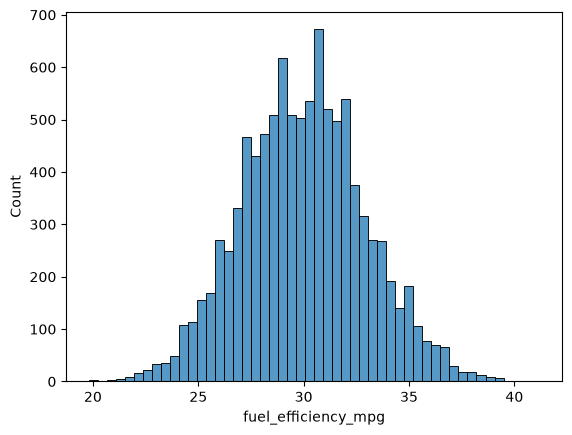

In [13]:
#Getting a Graph of fuel_efficiency_mpg

sns.histplot(df_new.fuel_efficiency_mpg, bins=50)

#The data has a normal distribution

In [16]:
#Looking for the median in horsepower

print(df_new.horsepower.median())

254.0


In [25]:
#Q3 preparing dataset

n =len(df_new)
n_val = int(n*0.2)
n_test = int(n*0.2)
n_train = n - n_val - n_test

#print(n_val, n_test, n_train) Just checking the total value is OK

np.random.seed(42)
idx = np.arange(n)
np.random.shuffle(idx)

df_train = df_new.iloc[idx[:n_train]]
df_val = df_new.iloc[idx[n_train:n_train + n_val]]
df_test = df_new.iloc[idx[n_train + n_val:]]

print(df_train.info())


<class 'pandas.core.frame.DataFrame'>
Index: 6000 entries, 6252 to 3252
Data columns (total 5 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   engine_displacement  6000 non-null   int64  
 1   horsepower           5462 non-null   float64
 2   vehicle_weight       6000 non-null   int64  
 3   model_year           6000 non-null   int64  
 4   fuel_efficiency_mpg  6000 non-null   float64
dtypes: float64(2), int64(3)
memory usage: 281.2 KB
None


In [109]:
#Resseting the idx
df_train = df_train.reset_index(drop=True)
df_val = df_val.reset_index(drop=True)
df_test = df_test.reset_index(drop=True)

In [110]:
#Setting the target value
y_train = df_train.fuel_efficiency_mpg.values
y_val = df_val.fuel_efficiency_mpg.values
y_test = df_test.fuel_efficiency_mpg.values



In [111]:
#Setting the data and filling Values with 0

X_train = df_train.fillna(0).values
X_val = df_val.fillna(0).values
X_test = df_test.fillna(0).values

print(X_train)

[[2250.   250.  4040.  2006.    35.5]
 [2190.   244.  3980.  1986.    31.9]
 [2190.   242.  4190.  2021.    30.9]
 ...
 [2270.   233.  3960.  2014.    30.5]
 [2130.   244.  4310.  2020.    34.6]
 [2540.   273.  4410.  2010.    28.7]]


In [ ]:
#Setting the data with the mean values



X_train = df_train.fillna(df_train.mean()).values
X_val = df_val.fillna(df_val.mean()).values
X_test = df_test.fillna(df_test.mean()).values


In [74]:
print(len(y_val))#Checking the values

2000


In [112]:
#Removing the target from the df for dont se accidently

del df_train['fuel_efficiency_mpg']
del df_val['fuel_efficiency_mpg']
del df_test['fuel_efficiency_mpg']

In [113]:
def train_linear_regression(X,y):
    ones = np.ones(X.shape[0])
    X = np.column_stack([ones, X])

    XTX =  X.T.dot(X)
    XTX_inv = np.linalg.inv(XTX)
    w_full = XTX_inv.dot(X.T).dot(y)

    return w_full[0], w_full[1:]

In [114]:
w0, w = train_linear_regression(X_train, y_train)

In [115]:
y_pred = w0 + X_train.dot(w)

len(y_pred)

6000

<Axes: ylabel='Count'>

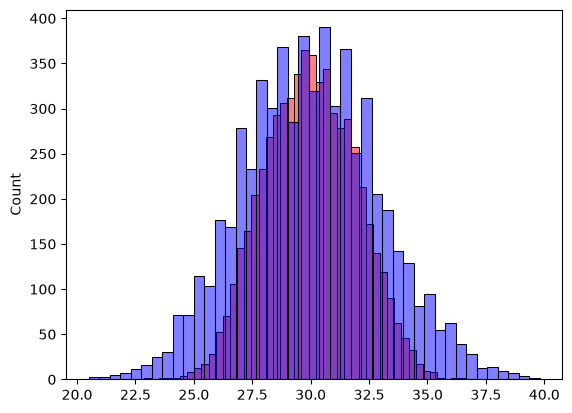

In [62]:
sns.histplot(y_pred, color='red', alpha=0.5)
sns.histplot(y_train, color='blue', alpha=0.5)

In [116]:
#RMSE

def rmse(y, y_pred):
    error = y-y_pred
    se = error **2
    mse=se.mean()

    return np.sqrt(mse)

In [124]:
rmse(y_train, y_pred)

np.float64(2.9903912122159635e-10)

In [82]:
y_pred_val = w0 + X_val.dot(w)

In [120]:
rmse(y_val, y_pred_val)

np.float64(3.4846443154762623)

In [85]:
#Regularization
def train_linear_regression_reg(X,y, r=0.001):
    ones = np.ones(X.shape[0])
    X = np.column_stack([ones, X])

    XTX =  X.T.dot(X)

    XTX = XTX + r * np.eye(XTX.shape[0])
    XTX_inv = np.linalg.inv(XTX)
    w_full = XTX_inv.dot(X.T).dot(y)

    return w_full[0], w_full[1:]

In [106]:
w0, w = train_linear_regression_reg(X_train, y_train, r=0.0)
y_pred = w0 + X_train.dot(w)

len(y_pred)

6000

In [107]:
#RMSE 

rmse(y_train, y_pred)

np.float64(2.2001846833713965)

In [128]:
seed_values = [0,1,2,3,4,5,6,7,8,9]

In [ ]:
#Q5 preparing dataset

val_rmse_total = 0

for i in range(len(seed_values)):
    n =len(df_new)
    n_val = int(n*0.2)
    n_test = int(n*0.2)
    n_train = n - n_val - n_test

    #print(n_val, n_test, n_train) Just checking the total value is OK

    np.random.seed(i)
    #print(i)
    idx = np.arange(n)
    np.random.shuffle(idx)

    df_train = df_new.iloc[idx[:n_train]]
    df_val = df_new.iloc[idx[n_train:n_train + n_val]]
    df_test = df_new.iloc[idx[n_train + n_val:]]

    df_train = df_train.reset_index(drop=True)
    df_val = df_val.reset_index(drop=True)
    df_test = df_test.reset_index(drop=True)

    #Setting the target value
    y_train = df_train.fuel_efficiency_mpg.values
    y_val = df_val.fuel_efficiency_mpg.values
    y_test = df_test.fuel_efficiency_mpg.values

    #Setting the data and filling Values with 0

    X_train = df_train.fillna(0).values
    X_val = df_val.fillna(0).values
    X_test = df_test.fillna(0).values

    #Removing the target from the df for dont se accidently

    del df_train['fuel_efficiency_mpg']
    del df_val['fuel_efficiency_mpg']
    del df_test['fuel_efficiency_mpg']

    w0, w = train_linear_regression(X_train, y_train)

    y_pred = w0 + X_train.dot(w)

    #print(y_pred)

    val_rmse=rmse(y_train, y_pred)
    #print(val_rmse)

    val_rmse_total = val_rmse_total+val_rmse

    print(val_rmse_total)

print(np.std(val_rmse_total))

    
